## **Práctica 2 - Infraestructuras y Tecnologías Big Data**

Senén Martínez Andreu,

Jorge Tomás Linares,

May Yun Amorós Más

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime
import time
import itertools
import multiprocessing

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures

from scipy.stats import norm
from scipy.stats import ttest_ind, shapiro, levene, mannwhitneyu

## **CARGA DE DATOS**


In [ ]:


url = "https://cargar-csv-eda.s3.us-east-1.amazonaws.com/Dataset.csv"
df = pd.read_csv(url, sep = ';')
df = df.sort_values(by = 'patient_id')
for i in range(24,32):
  df.drop(columns='Unnamed: '+ str(i), inplace = True)
df.head(10)

,patient_id,patient_years_with_insurance_with_us,patient_last_year_regular_checkup,patient_participates_in_adventure_sports,patient_occupation,patient_visited_doctor_last_1_year,patient_cholesterol_level,patient_average_daily_steps,patient_age,patient_has_heart_disease_history,...,patient_smoking_status,patient_year_last_admitted,patient_location,patient_weight,patient_covered_by_other_insurance_company,patient_alcohol_consumption,patient_exercise_regimen,patient_weight_change_last_year,patient_body_fat_percentage,patient_insurance_cost
10878,5004,6,0,0,Business,2,200 to 225,4330,23,0,...,never smoked,NaN,Bhubaneswar,68,N,Rare,Moderate,4,42,20978
21307,5014,1,3,0,Student,4,125 to 150,6733,41,0,...,never smoked,NaN,Bhubaneswar,76,N,No,Moderate,2,33,37020
5103,5037,8,0,0,Business,5,175 to 200,6521,70,0,...,formerly smoked,1997.0,Bangalore,85,N,No,Moderate,4,37,43190
3634,5064,7,1,0,Student,4,125 to 150,4411,53,0,...,never smoked,1995.0,Delhi,70,N,No,Extreme,1,38,25914
769,5078,1,0,0,Business,2,175 to 200,5410,23,0,...,smokes,NaN,Delhi,66,N,No,Moderate,2,37,20978
18919,5088,0,0,0,Business,2,175 to 200,5812,27,0,...,never smoked,NaN,Ahmedabad,61,N,Rare,Moderate,5,37,8638
12047,5154,1,0,0,Business,3,175 to 200,4767,62,0,...,never smoked,NaN,Guwahati,61,N,No,Extreme,2,29,14808
21387,5159,3,1,0,Salried,2,225 to 250,6117,46,0,...,Unknown,2001.0,Mumbai,78,N,No,Extreme,2,31,34552
14577,5176,5,0,1,Salried,4,125 to 150,5393,58,0,...,never smoked,1991.0,Delhi,81,N,Daily,No,2,25,33318
3530,5184,8,0,0,Salried,2,125 to 150,6194,56,0,...,never smoked,2016.0,Ahmedabad,64,Y,Rare,Moderate,5,25,12340


## **DESCRIPCIÓN DE LOS DATOS**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 10878 to 7997
Data columns (total 24 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   patient_id                                  25000 non-null  int64  
 1   patient_years_with_insurance_with_us        25000 non-null  int64  
 2   patient_last_year_regular_checkup           25000 non-null  int64  
 3   patient_participates_in_adventure_sports    25000 non-null  int64  
 4   patient_occupation                          25000 non-null  object 
 5   patient_visited_doctor_last_1_year          25000 non-null  int64  
 6   patient_cholesterol_level                   25000 non-null  object 
 7   patient_average_daily_steps                 25000 non-null  int64  
 8   patient_age                                 25000 non-null  int64  
 9   patient_has_heart_disease_history           25000 non-null  int64  
 10  patient_has_

In [ ]:
df.shape

(25000, 24)

#### **Tamaño del dataset**:


*   Filas: 25000
*   Columnas: 24

#### **Descripción de las columnas:**

*   **patient_id:** id con el que se identifica a cada paciente.
*   **patient_years_with_insurance_with_us:** Los años que lleva el paciente asegurado con la compañía.
*   **patient_last_year_regular_checkup:** Indica el número de chequeos médicos que se hizo paciente en el último año.
*   **patient_participates_in_adventure_sports:** Indica si el paciente participa en deportes de aventura (binario: 0 no, 1 sí)
*   **patient_occupation:** La ocupación del paciente. Puede ser estudiante, asalariado o empresario.
*   **patient_visited_doctor_last_1_year:** Número de veces que el paciente fue al médico en el último año.
*   **patient_cholesterol_level:** Nivel del colesterol del paciente, por rangos.
*   **patient_average_daily_steps:** Número medio de pasos diarios que da el paciente.
*   **patient_age:** Edad del paciente.
*   **patient_has_heart_disease_history:** Antecendentes de problemas cardiacos en la familia del paciente (binario: 0 no, 1 sí).
*   **patient_has_other_major_disease_history:** Historial de otros problemas médicos importantes en la familia del paciente (binario: 0 no, 1 sí).
*   **patient_gender:** Género del paciente
*   **patient_average_glucose_level:** Nivel medio de glucosa en la sangre del paciente.
*   **patient_body_mass_index:** Índice de masa corporal (IMC o BMI) del paciente.
*   **patient_smoking_status:** Estado de fumador del paciente.
*   **patient_year_last_admitted:** El año del último reconocimiento médico del paciente.
*   **patient_location:** Localidad del paciente.
*   **patient_weight:** Peso del paciente (Kg).
*   **patient_covered_by_other_insurance_company:** Indica si el paciente está asegurado por otra compañía de seguros (binario: N no, Y sí).
*   **patient_alcohol_consumption:** Frecuencia consumo de alcohol del paciente.
*   **patient_exercise_regimen:** Cantidad de ejercicio que hace el paciente.
*   **patient_weight_change_last_year:** Peso que ha perdido el paciente en el último año (Kg).
*   **patient_body_fat_percentage:** Porcentaje de grasa del paciente.
*   **patient_insurance_cost:** El coste del precio del seguro del paciente.

#### **Columnas con valores nulos:**

In [ ]:
nulos = df.isnull().sum()
nulos[nulos > 0].to_frame(name="Cantidad_Nulos")

,Cantidad_Nulos
patient_body_mass_index,990
patient_year_last_admitted,11881


## **CODIFICACIÓN DE COLUMNAS CATEGÓRICAS**
Codificaremos las columnas categóricas para emplearlas más adelante tanto en el análisis de los datos como en modelos de predicción.

In [ ]:
map_cholesterol = {'125 to 150': 0, '150 to 175': 1, '175 to 200': 2, '200 to 225': 3, '225 to 250': 4}
df['patient_cholesterol_level_cod'] = df['patient_cholesterol_level'].map(map_cholesterol)

map_alcohol = {'No': 0, 'Rare': 1, 'Daily': 2}
df['patient_alcohol_consumption_cod'] = df['patient_alcohol_consumption'].map(map_alcohol)

map_exercise = {'No': 0, 'Moderate': 1, 'Extreme': 2}
df['patient_exercise_regimen_cod'] = df['patient_exercise_regimen'].map(map_exercise)

map_other_insurance = {'N': 0, 'Y': 1}
df['patient_other_insurance_cod'] = df['patient_covered_by_other_insurance_company'].map(map_other_insurance)

map_gender = {'Female': 0, 'Male': 1}
df['patient_gender_cod'] = df['patient_gender'].map(map_gender)

## **LIMPIEZA DEL DATASET**

### **Columna *patient_id***
Hay id's de pacientes que se repiten. Posibles causas:


*   Fallo del sistema al insertar nuevos datos haciendo que se ponga el mismo id a personas diferentes.
*   Un mismo paciente puede dejar la aseguradora y luego volver.




In [ ]:
# Mostramos que hay id's duplicados
patient_value = df['patient_id'].value_counts()
print(patient_value.loc[patient_value > 1])

patient_id
243147    4
86474     3
64030     3
235938    3
189341    3
         ..
102447    2
45924     2
242180    2
122682    2
124209    2
Name: count, Length: 1229, dtype: int64


In [ ]:
# Mostramos los datos de pacientes con id's repetidos
df[df['patient_id'].isin(patient_value.index[patient_value > 1])].sort_values(by = 'patient_id')

,patient_id,patient_years_with_insurance_with_us,patient_last_year_regular_checkup,patient_participates_in_adventure_sports,patient_occupation,patient_visited_doctor_last_1_year,patient_cholesterol_level,patient_average_daily_steps,patient_age,patient_has_heart_disease_history,...,patient_alcohol_consumption,patient_exercise_regimen,patient_weight_change_last_year,patient_body_fat_percentage,patient_insurance_cost,patient_cholesterol_level_cod,patient_alcohol_consumption_cod,patient_exercise_regimen_cod,patient_other_insurance_cod,patient_gender_cod
13840,5355,7,0,0,Student,4,150 to 175,6068,42,0,...,Rare,Moderate,3,15,24680,1,1,1,0,1
24249,5355,5,0,0,Student,4,125 to 150,5176,46,0,...,Rare,Moderate,1,33,29616,0,1,1,1,1
17786,5559,4,0,0,Salried,3,125 to 150,3610,27,0,...,No,Extreme,2,19,49360,0,0,2,1,1
8578,5559,8,0,0,Salried,2,225 to 250,7495,46,0,...,Rare,Moderate,3,31,35786,4,1,1,0,1
6092,6016,5,3,1,Salried,2,125 to 150,8452,72,0,...,Rare,Extreme,4,12,25914,0,1,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18149,248955,0,5,0,Business,6,150 to 175,4171,50,0,...,No,Extreme,3,36,35786,1,0,2,0,0
13770,249280,8,0,0,Business,4,175 to 200,5042,45,0,...,No,No,4,29,57998,2,0,0,0,1
13001,249280,1,0,0,Business,3,175 to 200,4986,44,1,...,No,Moderate,4,29,38254,2,0,1,0,1
12819,249717,0,0,0,Student,2,150 to 175,5361,48,0,...,Rare,No,1,24,34552,1,1,0,0,1


Al haber id's repetidos y no observarse un patrón claro entre los datos de las filas con el mismo id que nos podría indicar la procedencia de la repetición de id's, supondremos que los id's que se repiten provienen de pacientes diferentes y optaremos por resetear la columna *patient_id*

In [ ]:
# Eliminamos la columna 'patient_id' y creamos el índice
df = df.drop(columns = 'patient_id')
df.index = range(1, len(df) + 1) # el patient_id empezará en 1
df.index.name = "patient_id"

In [ ]:
df.head()

,patient_years_with_insurance_with_us,patient_last_year_regular_checkup,patient_participates_in_adventure_sports,patient_occupation,patient_visited_doctor_last_1_year,patient_cholesterol_level,patient_average_daily_steps,patient_age,patient_has_heart_disease_history,patient_has_other_major_disease_history,...,patient_smoking_status,patient_year_last_admitted,patient_location,patient_weight,patient_covered_by_other_insurance_company,patient_alcohol_consumption,patient_exercise_regimen,patient_weight_change_last_year,patient_body_fat_percentage,patient_insurance_cost
patient_id,,,,,,,,,,,,,,,,,,,,,
1,6,0,0,Business,2,200 to 225,4330,23,0,0,...,never smoked,NaN,Bhubaneswar,68,N,Rare,Moderate,4,42,20978
2,1,3,0,Student,4,125 to 150,6733,41,0,0,...,never smoked,NaN,Bhubaneswar,76,N,No,Moderate,2,33,37020
3,8,0,0,Business,5,175 to 200,6521,70,0,0,...,formerly smoked,1997.0,Bangalore,85,N,No,Moderate,4,37,43190
4,7,1,0,Student,4,125 to 150,4411,53,0,0,...,never smoked,1995.0,Delhi,70,N,No,Extreme,1,38,25914
5,1,0,0,Business,2,175 to 200,5410,23,0,0,...,smokes,NaN,Delhi,66,N,No,Moderate,2,37,20978


### **Columna *patient_year_last_admitted***

Los valores nulos de la columna *patient_last_admitted* se deben a que los pacientes nunca han sido ingresados. Para tratar estos valores nulos, crearemos tres columnas:

*   **patient_last_admitted:** indica si un paciente ha sido ingresado o no (binaria: 0 no, 1 sí).
*   **patient_years_since_last_admitted:** años desde el último ingreso. En el caso de que no haya sido ingresado, le asignaremos el valor -1.
*   **patient_years_since_last_admitted_cod:** años desde el último ingreso, divididas en rangos de 5 años.





In [ ]:
# Número de valores nulos de la columna 'patient_year_last_admitted'
print('Valores nulos:',df['patient_year_last_admitted'].isna().sum())

Valores nulos: 11881


In [ ]:
# Separamos a los pacientes que han sido ingresados alguna vez o no en la columna 'patient_last_admitted'.
df['patient_last_admitted'] = np.where(df['patient_year_last_admitted'].isna(), 0, 1)

# Calculamos cuantos años hace del último ingreso. Si nunca han sido ingresados, asignaremos -1.
df['patient_years_since_last_admitted'] = np.where(
    df['patient_year_last_admitted'].isna(), -1,
    datetime.datetime.now().year - df['patient_year_last_admitted']
).astype(int)

def convert_years(x):
  if x <= 0:
    return 0 # Nunca ha sido ingresado
  elif x <= 5:
    return 1 # 5 años o menos desde el último ingreso
  elif x <= 10:
    return 2 # 10 años o menos desde el último ingreso
  elif x <= 15:
    return 3 # 15 años o menos desde el último ingreso
  elif x <= 20:
    return 4 # 20 años o menos desde el último ingreso
  elif x <= 25:
    return 5 # 25 años o menos desde el último ingreso
  elif x <= 30:
    return 6 # 30 años o menos desde el último ingreso
  else:
    return 7 # más de 35 años desde el último ingreso

df['patient_years_since_last_admitted_cod'] = df['patient_years_since_last_admitted'].apply(convert_years)

# df.drop(columns = 'patient_year_last_admitted', inplace = True)

### **Columna *patient_body_mass_index***

Cambiaremos el tipo de dato de la columna *patient_body_mass_index* para que sea númerica y rellenaremos los valores nulos utilizando una regresión lineal para predecir el bmi.

In [ ]:
# Cambiamos el tipo de dato a float

df['patient_body_mass_index'] = df['patient_body_mass_index'].str.replace(',','.')
df['patient_body_mass_index'] = df['patient_body_mass_index'].astype(float)

El bmi se puede calcular a partir del peso y de la altura como:

$$
  bmi = \dfrac{\text{Peso en kg}}{(\text{Altura en metros})^2}
$$

Por lo tanto, el bmi debería de tener una alta correlación con el peso y con la altura del paciente. Sin embargo, como se muestra a continuación, la correlación con el peso es mínima. Esto nos indica que estos datos no son del todo fiables.

Por otro lado, también se observa que ninguna columna está altamente correlacionada con el bmi, por lo que los modelos de regresión lineal no funcionarán correctamente.

In [ ]:
features = [col for col in df.columns if df.dtypes[col] != 'object']

# Correlaciones de las variable numéricas con 'patient_body_mass_index'
correlations_bmi = df[features].corr()['patient_body_mass_index'].sort_values(ascending = False)
correlations_bmi

,patient_body_mass_index
patient_body_mass_index,1.000000
patient_gender_cod,0.339040
patient_has_other_major_disease_history,0.167062
patient_has_heart_disease_history,0.041052
patient_weight_change_last_year,0.018206
patient_id,0.005798
patient_year_last_admitted,0.004876
patient_exercise_regimen_cod,0.001716
patient_other_insurance_cod,0.001274
patient_visited_doctor_last_1_year,0.000522


Datos para los modelos de predicción del bmi.

In [ ]:
# Entrenaremos los modelos con las filas que no tienen bmi nulo

df_bmi = df[~df['patient_body_mass_index'].isna()]

#### **Modelo 1:** Seleccionamos las variables relacionadas con el peso (aquellas que la lógica dice que tienen que estar relacionadas).


In [ ]:
features_bmi_weight  = ['patient_weight', 'patient_body_fat_percentage', 'patient_has_heart_disease_history']

X = df_bmi[features_bmi_weight ]
y = df_bmi['patient_body_mass_index']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_bmi_weight  = LinearRegression()
model_bmi_weight .fit(X_train, y_train)

predict_bmi_weight  = model_bmi_weight .predict(X_test)
print(f'MSE: {round(np.sqrt(mean_squared_error(y_test, predict_bmi_weight )),2)}')
print(f'R2: {round(r2_score(y_test, predict_bmi_weight ),4)}')

MSE: 7.83
R2: 0.0008


#### **Modelo 2:** Nos quedamos con las variables que tienen mayor correlación con el bmi.

In [ ]:
features_bmi_cor = ['patient_has_other_major_disease_history', 'patient_gender_cod']
X = df_bmi[features_bmi_cor]
y = df_bmi['patient_body_mass_index']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_bmi_cor = LinearRegression()
model_bmi_cor.fit(X_train, y_train)

predict_bmi_cor = model_bmi_cor.predict(X_test)
print(f'MSE: {round(np.sqrt(mean_squared_error(y_test, predict_bmi_cor)),2)}')
print(f'R2: {round(r2_score(y_test, predict_bmi_cor),4)}')

MSE: 7.3
R2: 0.1301


#### **Modelo 3:** Usamos todas las variables.

In [ ]:
features_bmi_all  = [col for col in df_bmi.columns if df_bmi.dtypes[col] != 'object' and col !='patient_body_mass_index' and col != 'patient_year_last_admitted']
X = df_bmi[features_bmi_all]
y = df_bmi['patient_body_mass_index']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_bmi_all = LinearRegression()
model_bmi_all.fit(X_train, y_train)

predict_bmi_all = model_bmi_all.predict(X_test)
print(f'MSE: {round(np.sqrt(mean_squared_error(y_test, predict_bmi_all)),2)}')
print(f'R2: {round(r2_score(y_test, predict_bmi_all),4)}')



MSE: 7.3
R2: 0.1294


Observamos que, en los tres modelos, el coeficiente de determinación $(R^2)$ es muy pequeño, lo que nos indica que ninguno de estos es útil para predecir. A continuación, graficamos la distribución del bmi y de los errores de cada modelo para corroborarlo.

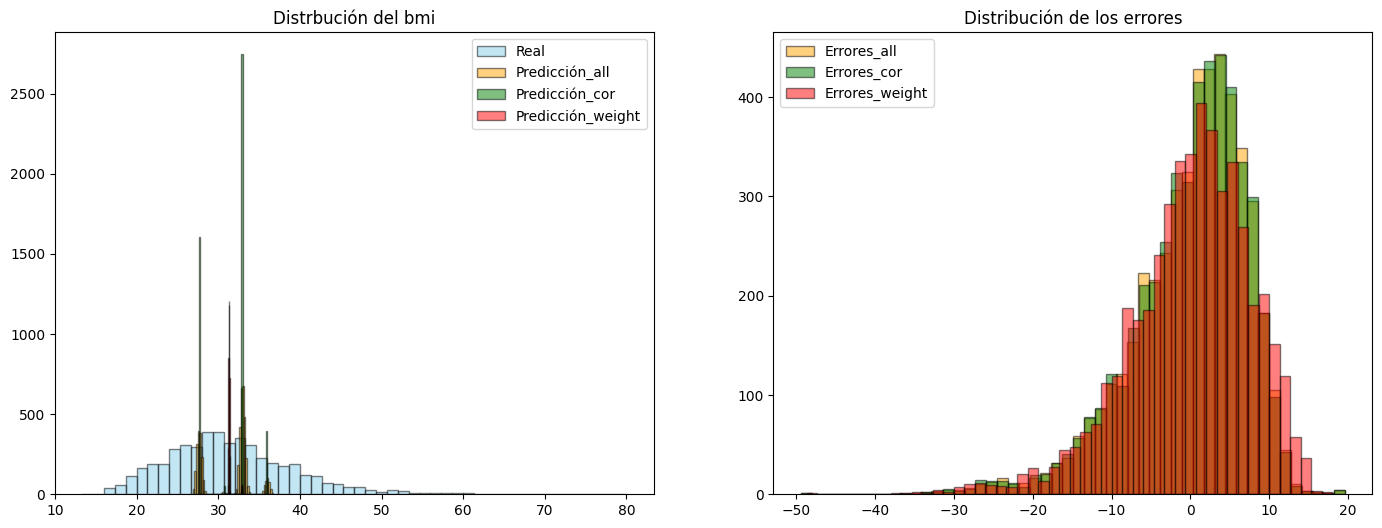

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

plt.subplot(1, 2, 1)
plt.hist(y_test, bins = 50, alpha = 0.5, label = 'Real', edgecolor = 'black', color= 'skyblue')
plt.hist(predict_bmi_all, bins = 50, alpha = 0.5, label = 'Predicción_all', edgecolor = 'black', color = 'orange')
plt.hist(predict_bmi_cor, bins = 50, alpha = 0.5, label = 'Predicción_cor', edgecolor = 'black', color = 'green')
plt.hist(predict_bmi_weight , bins = 50, alpha = 0.5, label = 'Predicción_weight', edgecolor = 'black', color = 'red')
plt.title('Distrbución del bmi')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Distribución de los errores')
plt.hist(sorted(predict_bmi_all-y_test), bins = 50, alpha = 0.5, label = 'Errores_all', edgecolor = 'black', color = 'orange')
plt.hist(sorted(predict_bmi_cor-y_test), bins = 50, alpha = 0.5, label = 'Errores_cor', edgecolor = 'black', color = 'green')
plt.hist(sorted(predict_bmi_weight -y_test), bins = 50, alpha = 0.5, label = 'Errores_weight', edgecolor = 'black', color = 'red')
plt.legend()

Viendo que los modelos anteriores no funcionan, rellenaremos los valores nulos del bmi con la media. Además, crearemos la columna *patient_bmi_category*, asignándole categorías a los pacientes en función de su nivel de obesidad.

In [ ]:
print('Media bmi:', df['patient_body_mass_index'].mean().round(2))

Media bmi: 31.39


In [ ]:
# Rellenamos con la media
df['patient_body_mass_index'] = df['patient_body_mass_index'].fillna(df['patient_body_mass_index'].mean())

# Asignamos categorías:
#   Bajo peso: Menos de 18.5
#   Peso saludable: 18.5 a 24.9
#   Sobrepeso: 25.0 a 29.9
#   Obesidad: 30.0 o más

def bmi_category(x):
  if x < 18.5:
    return 0 # Bajo peso
  elif x <= 24.9:
    return 1 # Peso saludable
  elif x <= 29.9:
    return 2 # Sobrepeso
  else:
    return 3 # Obesidad

df['patient_bmi_category'] = df['patient_body_mass_index'].apply(bmi_category)

##Mapa de correlaciones entre todas las variables

<Axes: >

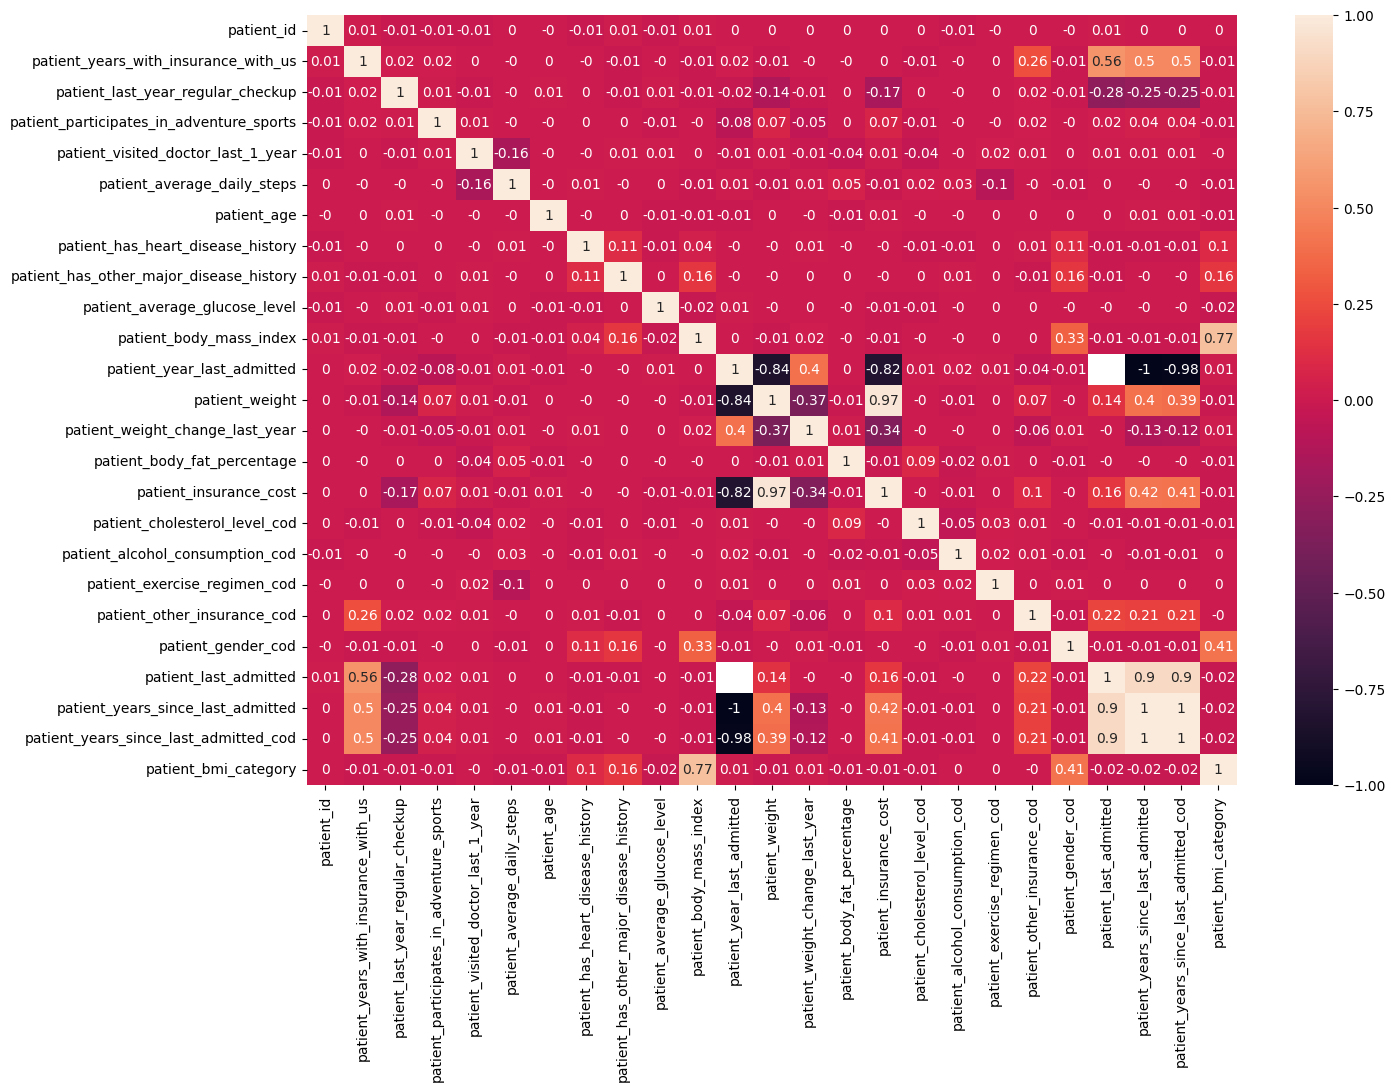

In [ ]:
features = [col for col in df.columns if df.dtypes[col] != 'object']
plt.figure(figsize = (15,10))
sns.heatmap(df[features].corr().round(2), annot=True)

## **ANÁLISIS DE LOS DATOS Y PREDICCIÓN**

#### **PREGUNTA 1 :**
**¿Los individuos con bajo BMI tienen un precio mayor de seguro que aquellos con alto BMI?**


In [ ]:
df_flaco = df[df['patient_bmi_category'] == 0]
df_obeso = df[df['patient_bmi_category'] == 3]

value_flaco = df_flaco['patient_insurance_cost'].mean()
value_obeso = df_obeso['patient_insurance_cost'].mean()

print('Media del seguro de los pacientes que tienen bajo BMI:   ',value_flaco)
print('Media del seguro de los pacientes que tienen alto BMI:   ',value_obeso)

Media del seguro de los pacientes que tienen bajo BMI:    27912.15062761506
Media del seguro de los pacientes que tienen alto BMI:    26989.948102638235


Aunque las medias sean diferentes, no podemos decir que estadísticamente sean diferentes.

Hay que hacer un test de comparación de medias. Planteamos el contraste de hipótesis.


$$
      \begin{cases}
         H_0 :& \mu_0 = \mu_1\\
         H_1 :& \mu_0 \neq \mu_1
      \end{cases},
$$

donde $\mu_0$ es la media de el grupo flaco y $\mu_1$ es la media del grupo obeso.

Vamos a comparar ahora si la diferencia de las medias es significativa. Para ello, primero comprobamos la normalidad.

In [ ]:
list_flaco = df_flaco['patient_insurance_cost'].values.tolist()
list_obeso = df_obeso['patient_insurance_cost'].values.tolist()

grupo1  = list_flaco
grupo2  = list_obeso

# Verificar normalidad ---
print(shapiro(grupo1))
print(shapiro(grupo2))


ShapiroResult(statistic=np.float64(0.9733132413085557), pvalue=np.float64(1.1844138739342617e-07))
ShapiroResult(statistic=np.float64(0.9695821116639192), pvalue=np.float64(1.0584803224812909e-46))


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13835.
  res = hypotest_fun_out(*samples, **kwds)


Como los grupos no poseen valores con distribución normal, no podemos usar una t-student. Usamos el test de MANN.

In [ ]:
u_stat, p_value = mannwhitneyu(grupo1, grupo2, alternative='two-sided')

print('Resultados del test de mannwhitneyu')

print('------------------------------------')

print(p_value)

Resultados del test de mannwhitneyu
------------------------------------
0.16693259551729933


Como el p-valor $> 0.05$, entonces no hay diferencia entre los grupos. No podemos descartar la hipótesis nula y podemos decir que los grupos tienen estadísticamente la misma media.

#### **PREGUNTA 2:**
**¿Los pacientes que practican deportes de aventura tienen distinta media de precio de seguro?**

In [ ]:
df_adventure = df[df['patient_participates_in_adventure_sports'] == 1]
df_no_adventure = df[df['patient_participates_in_adventure_sports'] == 0]

value_adventure = df_adventure['patient_insurance_cost'].mean()
value_no_adventure = df_no_adventure['patient_insurance_cost'].mean()

print('Media del seguro de los pacientes que practican deporte de aventura:   ',value_adventure)
print('Media del seguro de los pacientes que no practican deporte de aventura:',value_no_adventure)

# Aunque las medias sean diferentes, no podemos decir que estadísticamente sean diferentes, hay que hacer un test de comparación de medias.

Media del seguro de los pacientes que practican deporte de aventura:    30727.385217816936
Media del seguro de los pacientes que no practican deporte de aventura: 26828.816657228734


Se procede análogamente a la pregunta 1. Vemos normalidad.

In [ ]:
list_adventure = df_adventure['patient_insurance_cost'].values.tolist()
list_no_adventure = df_no_adventure['patient_insurance_cost'].values.tolist()

grupo1  = list_adventure
grupo2  = list_no_adventure

# Verificar normalidad  ---
print(shapiro(grupo1))
print(shapiro(grupo2))

print('--------------------------------------------------')

ShapiroResult(statistic=np.float64(0.987314048819745), pvalue=np.float64(1.8140913976021938e-12))
ShapiroResult(statistic=np.float64(0.9681063871758071), pvalue=np.float64(3.3095300673189027e-56))
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 22957.
  res = hypotest_fun_out(*samples, **kwds)


Como los grupos no poseen valores con distribución normal, no podemos usar una t-student. Usamos el test de MANN.

In [ ]:
u_stat, p_value = mannwhitneyu(grupo1, grupo2, alternative='two-sided')

print('Resultados del test de mannwhitneyu')

print('------------------------------------')

print(p_value)

Resultados del test de mannwhitneyu
------------------------------------
1.6170828113350984e-35


Como el p-valor $= 1.61 \cdot 10^{-35}$, quiere decir que la hipótesis nula  es descartada y, por tanto, nos quedamos con la alternativa. En consecuencia, podemos decir que las medias de los dos grupos son estadísticamente diferentes.

#### **PREGUNTA 3:**
**¿Existe alguna diferencia en el coste del seguro entre los individuos que nunca se han hecho un reconocimiento médico con los que sí?**

In [ ]:
# Dividimos el dataset en función de la columna anterior.
df_null_last_admitted = df[df['patient_last_admitted'] == 0]
df_last_admitted = df[df['patient_last_admitted'] == 1]

value_admited = df_last_admitted['patient_insurance_cost'].mean().round(4)
value_not_admited = df_null_last_admitted['patient_insurance_cost'].mean().round(4)

print('Media del seguro de los pacientes que nunca se han hecho un reconocimiento médicos:   ',value_not_admited)
print('Media del seguro de los pacientes que han sido ingresados:   ',value_admited)

Media del seguro de los pacientes que nunca se han hecho un reconocimiento médicos:    24677.1957
Media del seguro de los pacientes que han sido ingresados:    29384.5133


Procediendo de manera análoga:

In [ ]:
list_admited = df_last_admitted['patient_insurance_cost'].values.tolist()
list_not_admited = df_null_last_admitted['patient_insurance_cost'].values.tolist()

from scipy.stats import ttest_ind, shapiro, levene

grupo1  = list_admited
grupo2  = list_not_admited

# Verificar normalidad  ---
print(shapiro(grupo1))
print(shapiro(grupo2))

print('--------------------------------------------------')

ShapiroResult(statistic=np.float64(0.9725990637642532), pvalue=np.float64(4.177415963962535e-44))
ShapiroResult(statistic=np.float64(0.9656720445383566), pvalue=np.float64(3.2472234143055316e-46))
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13119.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11881.
  res = hypotest_fun_out(*samples, **kwds)


Como los grupos no poseen valores con distribución normal, no podemos usar una t-student. Usamos el test de MANN.

In [ ]:
u_stat, p_value = mannwhitneyu(grupo1, grupo2, alternative='two-sided')

print('Resultados del test de mannwhitneyu')

print('------------------------------------')

print(p_value)

Resultados del test de mannwhitneyu
------------------------------------
5.513446603235991e-147


Como el p-valor $= 5.51 \cdot 10^{-147}$, quiere decir que la hipótesis nula  es descartada y, por tanto, nos quedamos con la alternativa. En consecuencia, podemos decir que las medias de los dos grupos son estadísticamente diferentes.

#### **PREGUNTA 4:**

 1. **¿Si utilizamos todas las variables, cual es el error medio de la predicción utilizando el modelo lineal?**

2. **¿Si utilizamos las 4 variables más importantes, cuál es el error medio con un modelo lineal?**

3. **Al hacer un modelo con la interacción entre variables, ¿el modelo es mejor?**

##### **MODELO LINEAL CON TODAS LAS VARIABLES**



In [ ]:
features_ml = [c for c in df.select_dtypes(include=np.number).columns if c not in ['patient_insurance_cost', 'patient_year_last_admitted']]
X = df[features_ml]
y = df['patient_insurance_cost']

# División train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# PREGUNTA 4.1

# Configuramos un modelo lineal
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predecimos X_test
y_pred  = linear_model.predict(X_test)

# Extraemos una medida del error
mse = mean_squared_error(y_test, y_pred)
error_lm = np.sqrt(mse)
R2_lm = r2_score(y_test, y_pred)

print('R2           : ',R2_lm)
print('Error medio  : ',error_lm)

R2           :  0.942417633868346
Error medio  :  3413.8170033982633


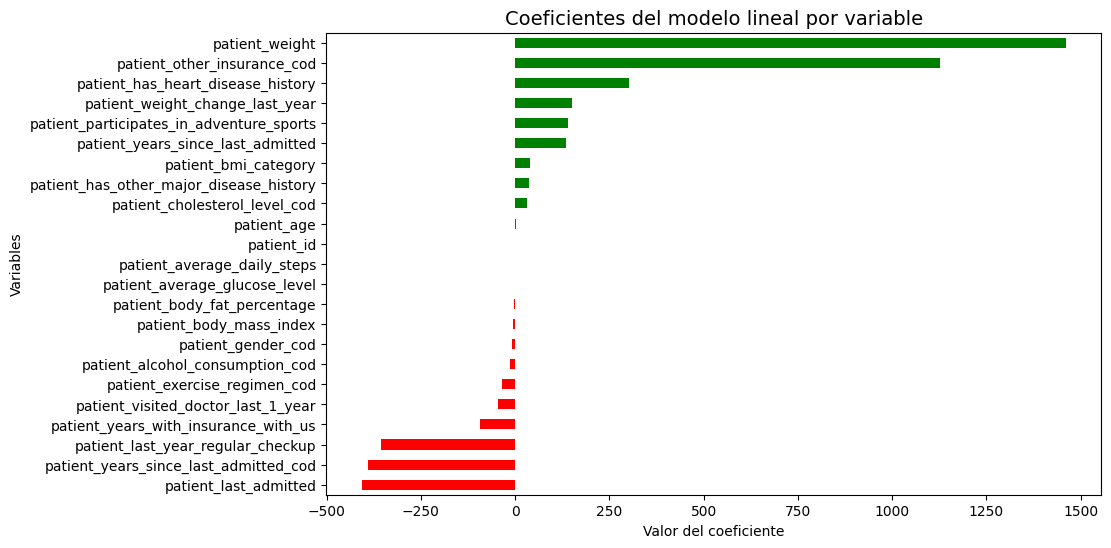

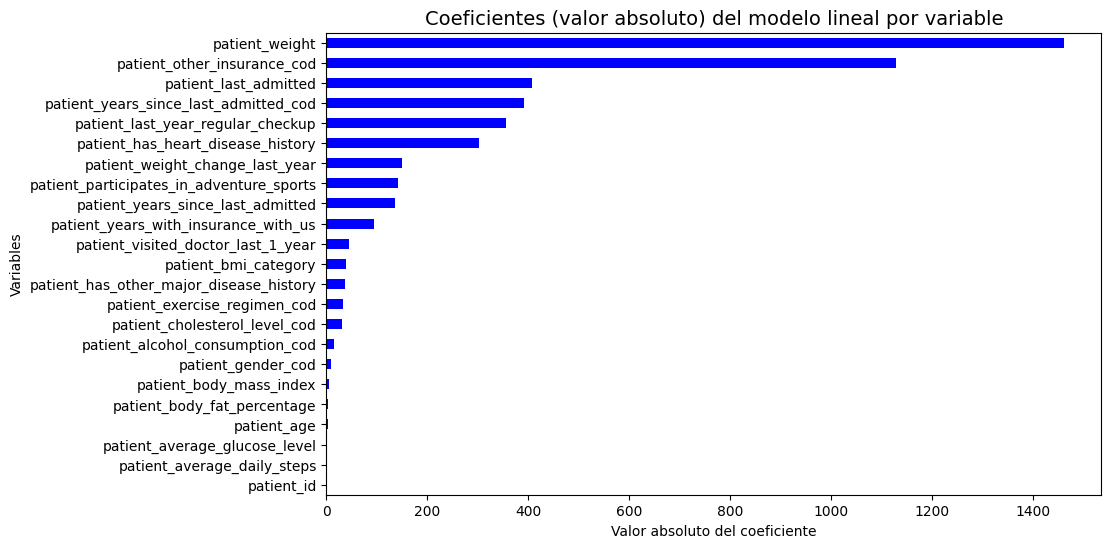

In [ ]:
#---------------------------------------------------------------------------
# Coeficientes de la regresión lineal
#---------------------------------------------------------------------------

coeficientes = pd.Series(linear_model.coef_, index=X.columns)

# Ordenamos por magnitud para mejor visualización
coeficientes = coeficientes.sort_values()

plt.figure(figsize=(10,6))
coeficientes.plot(kind='barh', color=['red' if c < 0 else 'green' for c in coeficientes])
plt.title("Coeficientes del modelo lineal por variable", fontsize=14)
plt.xlabel("Valor del coeficiente")
plt.ylabel("Variables")
plt.show()

#---------------------------------------------------------------------------
# Coeficientes de la regresión lineal en valor absoluto
#---------------------------------------------------------------------------

# Usamos el valor absoluto y los ordenamos
coeficientes_abs = coeficientes.abs().sort_values()

# Graficamos
plt.figure(figsize=(10,6))
coeficientes_abs.plot(kind='barh', color='blue')
plt.title("Coeficientes (valor absoluto) del modelo lineal por variable", fontsize=14)
plt.xlabel("Valor absoluto del coeficiente")
plt.ylabel("Variables")
plt.show()

##### **MODELO LINEAL CON UN SUBCONJUNTO DE 4 VARIABLES**


In [ ]:
# Unimos X e y temporalmente para calcular las correlaciones con la variable objetivo
df_corr = X.copy()
df_corr['patient_insurance_cost'] = y

# Calcular correlaciones con respecto a la variable objetivo
correlations = df_corr.corr()["patient_insurance_cost"].sort_values(ascending=False)

# Variables a excluir
excluir = ["patient_insurance_cost", "patient_years_since_last_admitted", "patient_last_admitted"]

# Eliminar del listado las variables a excluir
correlations = correlations.drop(excluir, errors='ignore')

# Número de columnas a seleccionar
N = 4

# Seleccionar las N variables más correlacionadas en valor absoluto
top_columns = correlations.abs().sort_values(ascending=False).head(N).index.tolist()

# Mostrar resultados
print("Correlaciones (sin las excluidas):")
print(correlations)
print("\nLas 4 variables más correlacionadas con el coste del seguro son:")
print(top_columns)

Correlaciones (sin las excluidas):
patient_weight                              0.970357
patient_years_since_last_admitted_cod       0.407783
patient_other_insurance_cod                 0.101624
patient_participates_in_adventure_sports    0.074561
patient_visited_doctor_last_1_year          0.008890
patient_age                                 0.005195
patient_exercise_regimen_cod                0.003646
patient_id                                  0.001611
patient_years_with_insurance_with_us        0.001404
patient_has_heart_disease_history          -0.000445
patient_cholesterol_level_cod              -0.001442
patient_gender_cod                         -0.002149
patient_has_other_major_disease_history    -0.002268
patient_average_glucose_level              -0.005007
patient_alcohol_consumption_cod            -0.006208
patient_average_daily_steps                -0.006565
patient_body_mass_index                    -0.008071
patient_body_fat_percentage                -0.008486
patient_bmi

In [ ]:
# 4.2
# Construimos X e y con las columnas más correlacionadas con el coste del seguro

X = df[top_columns]
y = df['patient_insurance_cost']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Configuramos un modelo lineal
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predecimos X_test
y_pred  = linear_model.predict(X_test)

# Extraemos una medida del error
mse = mean_squared_error(y_test, y_pred)
error_lm4 = np.sqrt(mse)
R2_lm4 = r2_score(y_test, y_pred)


print('Con 4 variables -------------------------')
print('R2           : ',R2_lm4)
print('Error medio  : ',error_lm4)

Con 4 variables -------------------------
R2           :  0.9409541090314785
Error medio  :  3456.9279182709743


##### **MODELO LINEAL CON INTERACCIONES**

In [ ]:
# 4.3. Modelo con interacciones

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.2, random_state=42)

linear_model_poly = LinearRegression()
linear_model_poly.fit(X_train_p, y_train_p)

y_pred_poly = linear_model_poly.predict(X_test_p)
rmse_poly = round(np.sqrt(mean_squared_error(y_test_p, y_pred_poly)),2)
R2_poly = round(r2_score(y_test_p, y_pred_poly),4)

print('Con interacciones -------------------------')
print('R2           : ',R2_poly)
print('Error medio  : ',rmse_poly)


print('----------------------------------------')
# Comparar resultados
print("RMSE modelo lineal simple:", error_lm)
print("RMSE modelo con interacciones:", rmse_poly)

# Es decir, el modelo con interacciones, tiene una tasa de error menor

Con interacciones -------------------------
R2           :  0.9462
Error medio  :  3298.53
----------------------------------------
RMSE modelo lineal simple: 3413.8170033982633
RMSE modelo con interacciones: 3298.53


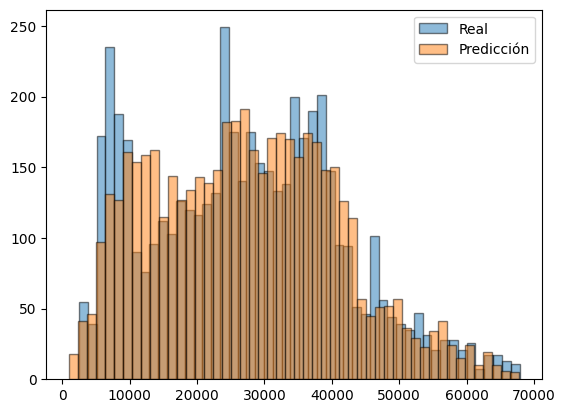

In [ ]:
plt.hist(y_test_p, bins = 50, alpha = 0.5, label = 'Real', edgecolor = 'black')
plt.hist(y_pred_poly, bins = 50, alpha = 0.5, label = 'Predicción', edgecolor = 'black')
plt.legend()

# Vemos como difieren los individuos reales de la predicción

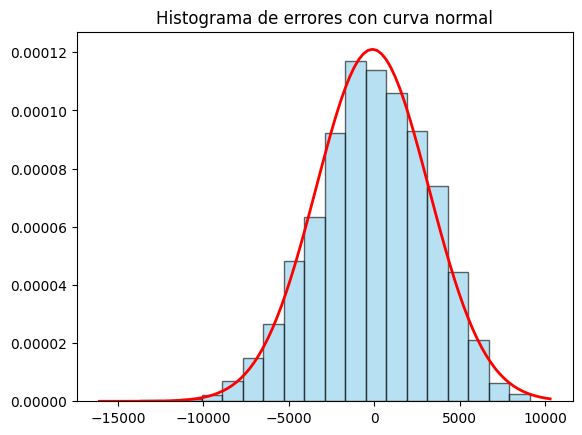

In [ ]:
from scipy.stats import norm
errores = np.sort(y_pred_poly - y_test_p)
mu, sigma = np.mean(errores), np.std(errores)

plt.hist(errores, bins=20, density=True, alpha=0.6, color='skyblue', edgecolor='black')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, 'r', linewidth=2)
plt.title("Histograma de errores con curva normal")
plt.show()

#  Aqui podemos observar que los errores siguen una distribución normal:

El mejor modelo dentro de los 3 lineales que hemos capturado es el que incluye las interacciones entre las 4 variables más significativas

#### **PREGUNTA 5** :



1.   **¿Existe algún modelo tipo árbol o random forest que sea capaz de predecir mejor que el de la pregunta 4?**
2.   **¿Cuál es el error medio?**






In [ ]:
# Separamos la variable objetivo 'patient_insurance_cost' del resto
features_ml = [c for c in df.select_dtypes(include=np.number).columns if c not in ['patient_insurance_cost', 'patient_year_last_admitted']]
X = df[features_ml]
y = df['patient_insurance_cost']

# División train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### **Árbol de decisión**
Entrenaremos varios árboles de decisión probando diferentes combinaciones de los parámetros *max_depth* (profundidad del árbol) y *min_samples_split* (número mínimo de muestras para dividir un nodo del árbol), con el objetivo de encontrar el mejor árbol de decisión que prediga el coste del seguro.

In [ ]:
# Tiempo inicial.
start_time_ini = time.time()

# Lista para almacenar los tiempos de ejecución.
list_time_dt = []
start_time = time.time()

# Lista para almacenar el Error Cuadrático Medio de cada modelo.
list_errors_dt = []
error_umbral_dt = 3100

# Lista para almacenar el R2 de cada modelo.
list_R2_dt = []

# Profundidad del árbol y número mínimo de muestras para dividir cada nodo
max_depth = np.arange(2,31)
min_samples_split = np.arange(2,8)

for i in max_depth:
  for j in min_samples_split:

    # Entrenamiento del modelo.
    model_tree = DecisionTreeRegressor(
        criterion='squared_error',
        splitter = 'best',
        max_depth = i,
        min_samples_split = j,
        min_samples_leaf = 1,
        max_leaf_nodes = None,
        min_impurity_decrease = 0,
        max_features = None,
        ccp_alpha = 0
    )

    model_tree.fit(X_train, y_train)
    y_pred_dt = model_tree.predict(X_test)

    # Añadimos el error, el tiempo de ejecución de cada Random Forest y el R2 en la lista correspondiente.
    time_value = round(time.time() - start_time,2)
    list_time_dt.append(time_value)

    error_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
    list_errors_dt.append(error_dt)

    R2_dt = round(r2_score(y_test, y_pred_dt),4)
    list_R2_dt.append(R2_dt)

    start_time = time.time()

    # Selección del mejor modelo.
    if error_dt <= error_umbral_dt:
      error_umbral_dt = error_dt
      model_tree_final = model_tree
      y_pred_final_dt = y_pred_dt
      best_depth = i
      best_samples_split = j
      best_time_dt = time_value
      best_R2_dt = R2_dt
      start_time = time.time()

end_time = time.time()
execution_time = end_time - start_time_ini
print(f"Tiempo de ejecución: {round(execution_time,2)} segundos")

Tiempo de ejecución: 49.43 segundos


In [ ]:
# Producto cartesiano de los valores de max_depth con min_samples_split
combinations = list(itertools.product(max_depth, min_samples_split)) # Producto cartesiano de los valores de max_depth con min_samples_split

# Dataframe con los valores de Error, Time y R2 para cada pareja de valores Estimators-Depth.
df_error = pd.DataFrame(combinations, columns=["Depth", "Sample_split"])
df_error["Error"] = list_errors_dt
df_error["Time"] = list_time_dt
df_error["R2"] = list_R2_dt

# Crear pivot table
pivot_error_dt = df_error.pivot(index='Sample_split', columns='Depth', values='Error')
pivot_time_dt = df_error.pivot(index='Sample_split', columns='Depth', values='Time')
pivot_R2_dt = df_error.pivot(index='Sample_split', columns='Depth', values='R2')


Text(0.5, 0, 'Depth')

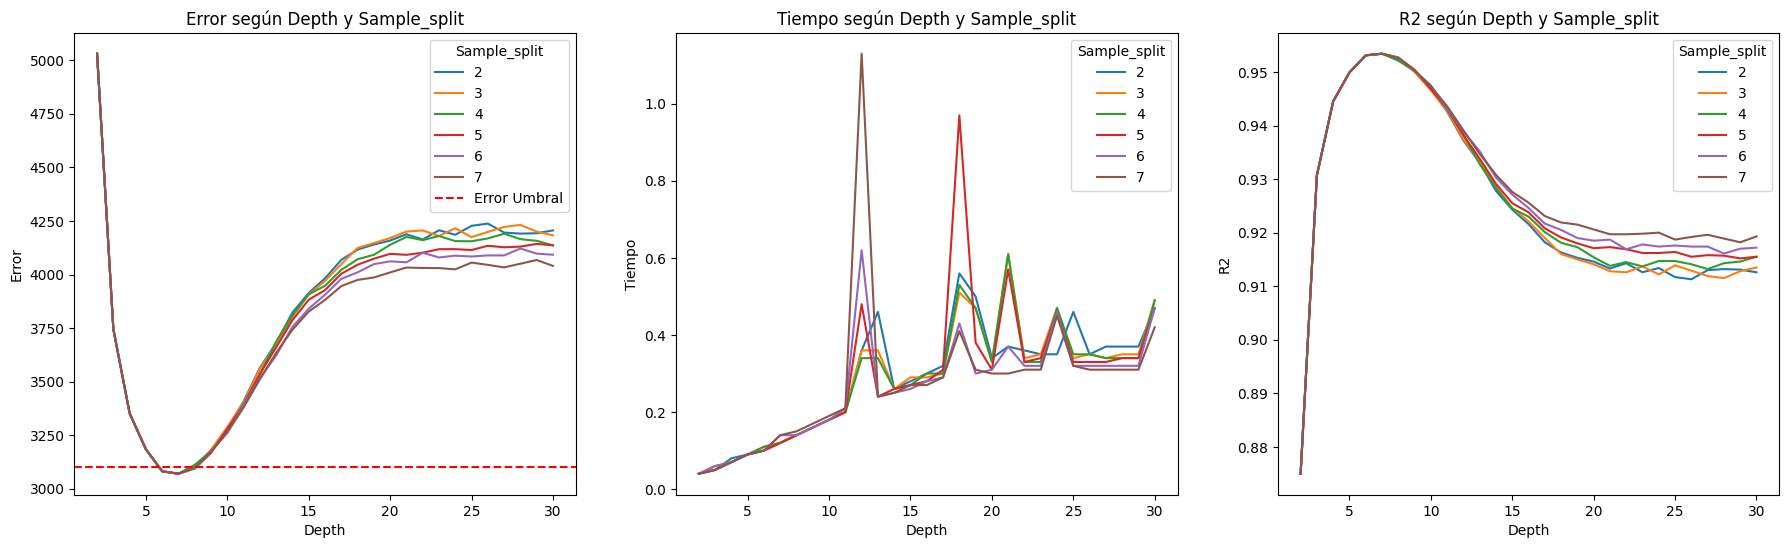

In [ ]:
# Representación gráfica de la evolución del MSE, el tiempo y el R2 en función de los parámetros.

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

plt.subplot(1, 3, 1)
for i in range(pivot_error_dt.shape[0]):
  pivot_error_dt.iloc[i,].plot(label = i + 2)
plt.axhline(y = 3100, color='r', linestyle='--', label = 'Error Umbral')
plt.legend(title = 'Sample_split')
plt.title("Error según Depth y Sample_split")
plt.ylabel("Error")
plt.xlabel("Depth")

plt.subplot(1, 3, 2)
for i in range(pivot_time_dt.shape[0]):
  pivot_time_dt.iloc[i,].plot(label = i + 2)
plt.legend(title = 'Sample_split')
plt.title("Tiempo según Depth y Sample_split")
plt.ylabel("Tiempo")
plt.xlabel("Depth")

plt.subplot(1, 3, 3)
for i in range(pivot_R2_dt.shape[0]):
  pivot_R2_dt.iloc[i,].plot(label = i + 2)
plt.legend(title = 'Sample_split')
plt.title("R2 según Depth y Sample_split")
plt.ylabel("R2")
plt.xlabel("Depth")

Para todos los valores de *min_sample_split* observamos que el MSE sigue la misma tendencia. Este valor alcanza siempre su mínimo para una profundidad del árbol de aproximadamente 7 y, a medida que aumenta la profundiad, el MSE crece hasta llegar un punto (entorno a la profundiad 22) en el que no cambia su monotomía.

También podemos observar que, para la profundidad 7, conseguimos el mejor valor para R2 y, a partir de dicha profunidad, el coeficiente de determinación empeora. Además, se aprecia también que, el hecho de aumentar la profundidad del árbol, hace que el tiempo de ejecución sea mayor.

A continuación, se muestran los parámetros del mejor árbol y las métricas asociadas a este.


In [ ]:
print(f'Profundidad del árbol: {best_depth}')
print(f'Número mínimo de muestras para dividir un nodo: {best_samples_split}')
print(f'Error Cuadrático Medio: {round(error_umbral_dt,2)}')
print(f'Tiempo de ejecución: {round(best_time_dt,2)} segundos')
print(f'R2: {best_R2_dt}')

Profundidad del árbol: 7
Número mínimo de muestras para dividir un nodo: 7
Error Cuadrático Medio: 3070.67
Tiempo de ejecución: 0.14 segundos
R2: 0.9534


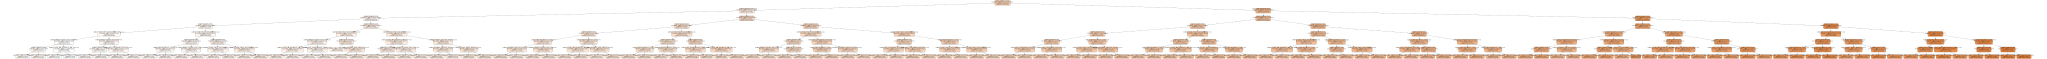

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

# Crear gráfico interactivo
dot_data = export_graphviz(
    model_tree_final,
    out_file=None,
    feature_names=features_ml,
    filled=True,
    proportion=True,
    rounded=True
)

# Mostramos árbol de decisión (No podemos ponerlo bien gráficamente :( )
graphviz.Source(dot_data)

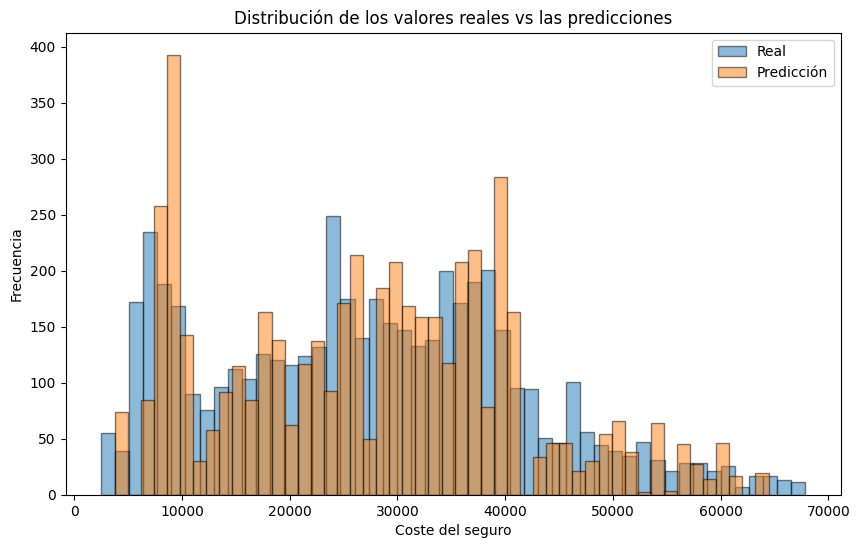

In [ ]:
# Comparación de la distribución de los valores reales de 'patient_insurance_cost' con las predicciones

plt.figure(figsize=(10, 6))
plt.hist(y_test, bins = 50, alpha = 0.5, label = 'Real', edgecolor = 'black')
plt.hist(y_pred_final_dt, bins = 50, alpha = 0.5, label = 'Predicción', edgecolor = 'black')
plt.title("Distribución de los valores reales vs las predicciones")
plt.xlabel("Coste del seguro")
plt.ylabel("Frecuencia")
plt.legend()

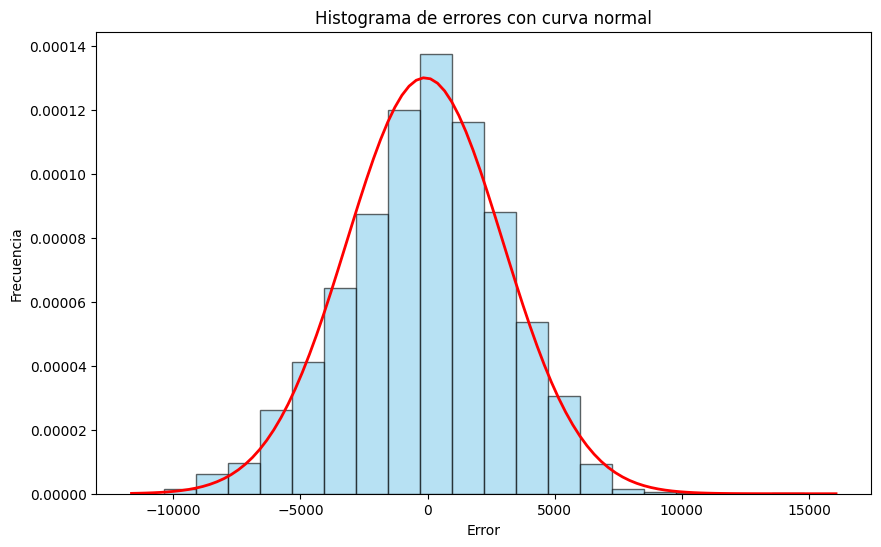

In [ ]:
# Distribución de los errores de las predicciones

errores_dt = np.sort(y_pred_final_dt - y_test)
mu, sigma = np.mean(errores_dt), np.std(errores_dt)

plt.figure(figsize=(10, 6))
plt.hist(errores_dt, bins=20, density=True, alpha=0.6, color='skyblue', edgecolor='black')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, 'r', linewidth=2)
plt.title("Histograma de errores con curva normal")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

Se puede observar que, debido a la alta correlación del peso con el coste del seguro, esta variable es la que más influye a la hora de construir el modelo.

In [ ]:
importances_dt = model_tree_final.feature_importances_
pd.DataFrame({'Variables': X.columns, 'Importancia': importances_dt}).sort_values(by = 'Importancia', ascending = False)

,Variables,Importancia
11,patient_weight,0.993044
20,patient_years_since_last_admitted,0.002145
17,patient_other_insurance_cod,0.001864
2,patient_last_year_regular_checkup,0.001120
21,patient_years_since_last_admitted_cod,0.000589
12,patient_weight_change_last_year,0.000540
1,patient_years_with_insurance_with_us,0.000227
6,patient_age,0.000109
9,patient_average_glucose_level,0.000104
0,patient_id,0.000084


##### **Random Forest**

Al igual que con los árboles de decisión, contruiremos varios random forest para poder encontrar el mejor. Los parámetros que cambiaremos serán el número de árboles de cada random forest y la profundidad de estos.

In [ ]:
# Tiempo inicial.
start_time_ini = time.time()

# Lista para almacenar los tiempos de ejecución.
list_time = []
start_time = time.time()

# Lista para almacenar el Errore Cuadrático Medio de cada modelo.
list_errors = []
error_umbral = 3100 # Umbral del error para elegir el mejor modelo

# Lista para almacenar el R2 de cada modelo.
list_R2 = []

# Profundidad de los árboles y número de árboles de cada Random Forest.
n_estimators = np.arange(20,29) # A partir de 20, el error cuadrático medio se estabiliza en torno a 3050
max_depth = np.arange(20,29)

# Nota: solo se construyen los random forest con los rangos de parámetros establecidos arriba debido
# al coste computacional que se requiere para la construcción de los random forest y a que no se obtiene
# mejoría tomando cualquier otra combinación de parámetros.


for i in n_estimators:
  for j in max_depth:

    # Entrenamiento del modelo.
    model_rforest = RandomForestRegressor(
            n_estimators = i,
            max_depth = j,
            min_samples_split = 35, # Número mínimo de muestras para dividir un nodo del árbol.
                                    # Mejora el tiempo de ejecución del random forest y evitamos sobreajuste.
            min_samples_leaf = 1,
            max_features = 8,
            bootstrap = True,
            oob_score = False,
            n_jobs = multiprocessing.cpu_count() # Usa todos los núcleos CPU en paralelo
            )

    model_rforest.fit(X_train, y_train)
    y_pred = model_rforest.predict(X_test)

    # Añadimos el error, el tiempo de ejecución de cada Random Forest y el R2 en la lista correspondiente.
    time_value = round(time.time() - start_time,2)
    list_time.append(time_value)

    error = round(np.sqrt(mean_squared_error(y_test, y_pred)),2)
    list_errors.append(error)

    R2 = round(r2_score(y_test, y_pred),4)
    list_R2.append(R2)

    start_time = time.time()

    # Selección del mejor modelo
    if error <= error_umbral:
      error_umbral = error
      model_rforest_final = model_rforest
      y_pred_final = y_pred

      best_estimator_estimators = i
      best_estimator_depth = j
      best_time = time_value
      best_R2 = R2
      start_time = time.time()

end_time = time.time()
execution_time = round(end_time - start_time_ini,2)
print(f"Tiempo total de ejecución: {execution_time} segundos")

Tiempo total de ejecución: 97.02 segundos


In [ ]:
# Producto cartesiano de los valores de max_depth con min_samples_split
combinations = list(itertools.product(n_estimators, max_depth))

# Dataframe con los valores de Error, Time y R2 para cada pareja de valores Estimators-Depth.
df_error = pd.DataFrame(combinations, columns=["Estimators", "Depth"])
df_error["Error"] = list_errors
df_error["Tiempo"] = list_time
df_error["R2"] = list_R2

# Pivot table para cada
pivot_error = df_error.pivot(index='Depth', columns='Estimators', values='Error')
pivot_time = df_error.pivot(index='Depth', columns='Estimators', values='Tiempo')
pivot_R2 = df_error.pivot(index='Depth', columns='Estimators', values='R2')

Text(0.5, 0, 'Estimators')

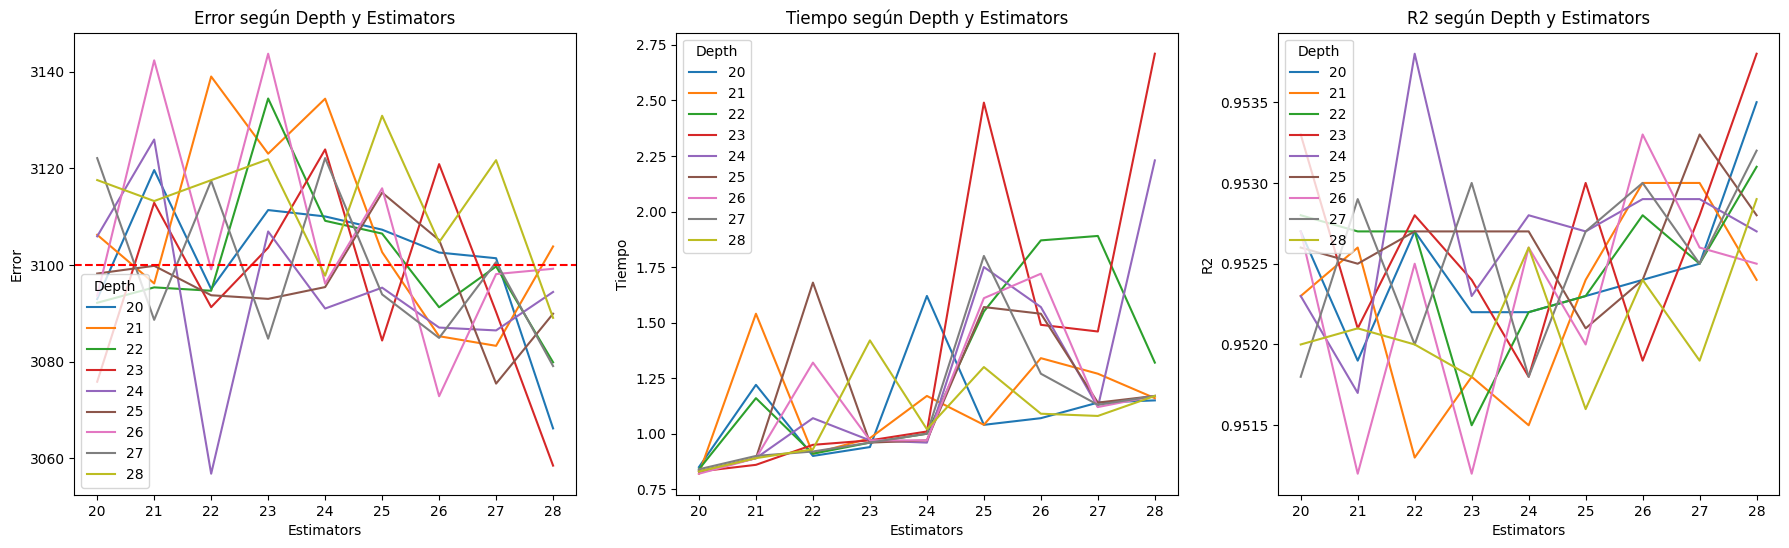

In [ ]:
# Representación gráfica de la evolución del MSE, el tiempo y el R2 en función de los parámetros.

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

plt.subplot(1, 3, 1)
for i in range(pivot_error.shape[0]):
  pivot_error.iloc[i,].plot(label = i + 20)

plt.axhline(y = 3100, color = 'r', linestyle='--')
plt.legend(title = 'Depth', loc = 'lower left')
plt.title("Error según Depth y Estimators")
plt.ylabel("Error")
plt.xlabel("Estimators")

plt.subplot(1, 3, 2)
for i in range(pivot_time.shape[0]):
  pivot_time.iloc[i,].plot(label = i + 20)
plt.legend(title = 'Depth')
plt.title("Tiempo según Depth y Estimators")
plt.ylabel("Tiempo")
plt.xlabel("Estimators")

plt.subplot(1, 3, 3)
for i in range(pivot_R2.shape[0]):
  pivot_R2.iloc[i,].plot(label = i + 20)
plt.legend(title = 'Depth', loc = 'upper left')
plt.title("R2 según Depth y Estimators")
plt.ylabel("R2")
plt.xlabel("Estimators")


Debido a que se toman muestras aleatorias de los datos para los árboles de cada random forest, tanto el MSE como el $R^2$ no siguen un patrón cuando el número de árboles aumenta, pero si se puede ver que incrementar el número de árboles implica un mayor tiempo de ejecución para la construcción de los modelos, así como que logramos alcanzar el umbral de error establecido con diferentes combinaciones estimator-depth.

Los parámetros del mejor random forest y sus métricas asociadas son las siguientes:

In [ ]:
print(f'Número de árboles: {best_estimator_estimators}')
print(f'Profundidad de los árboles: {best_estimator_depth}')
print(f'MSE: {error_umbral}')
print(f'R2: {best_R2}')
print(f'Tiempo de ejecución: {best_time}')


Número de árboles: 22
Profundidad de los árboles: 24
MSE: 3056.78
R2: 0.9538
Tiempo de ejecución: 1.07


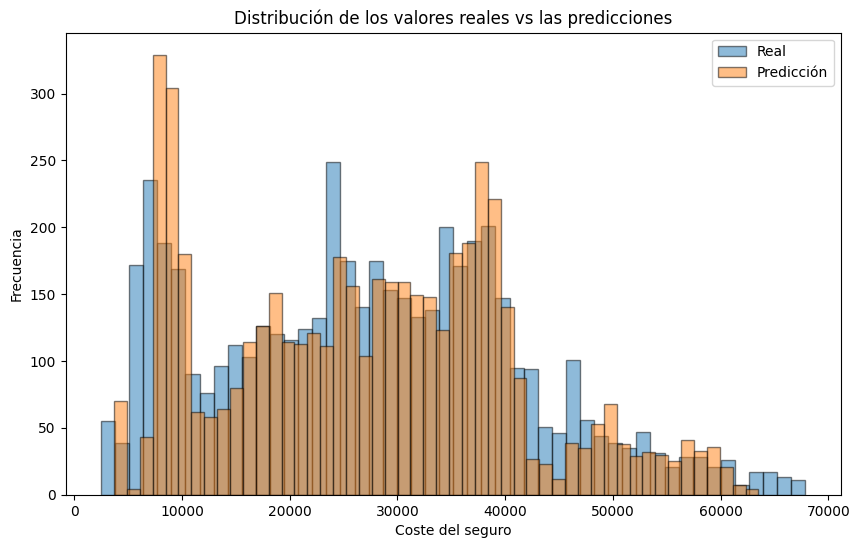

In [ ]:
# Comparación de la distribución de los valores reales de 'patient_insurance_cost' con las predicciones

plt.figure(figsize=(10, 6))
plt.hist(y_test, bins = 50, alpha = 0.5, label = 'Real', edgecolor = 'black')
plt.hist(y_pred_final, bins = 50, alpha = 0.5, label = 'Predicción', edgecolor = 'black')
plt.title("Distribución de los valores reales vs las predicciones")
plt.xlabel("Coste del seguro")
plt.ylabel("Frecuencia")
plt.legend()

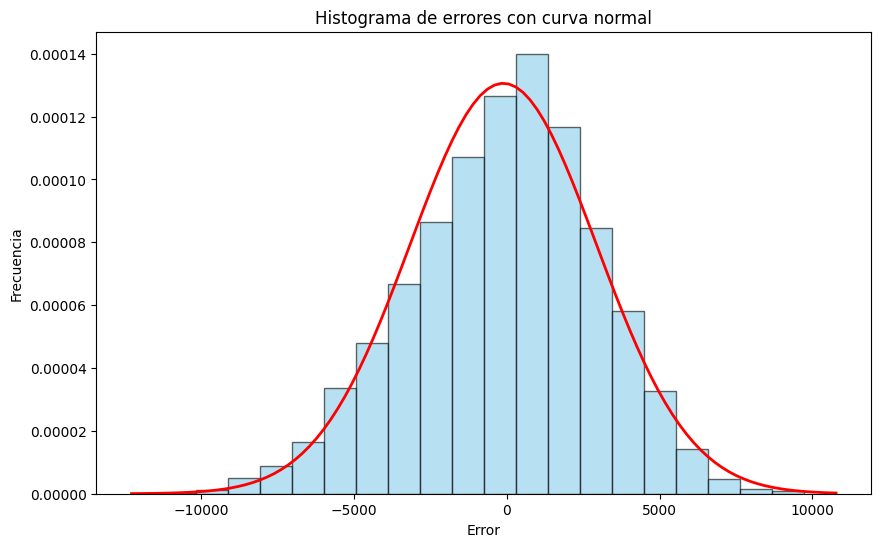

In [ ]:
# Distribución de los errores de las predicciones

errores = np.sort(y_pred_final - y_test)
mu, sigma = np.mean(errores), np.std(errores)

plt.figure(figsize=(10, 6))
plt.hist(errores, bins=20, density=True, alpha=0.6, color='skyblue', edgecolor='black')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, 'r', linewidth=2)
plt.title("Histograma de errores con curva normal")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()


Al igual que con el árbol de decisión, la variable más importante para el modelo es el peso del paciente. Sin embargo, en este caso vemos que también cobra relevancia para el random forest los años que han pasado desde la última vez que un paciente ha sido ingresado.

In [ ]:
importances = model_rforest_final.feature_importances_
pd.DataFrame({'Variables': X.columns, 'Importancia': importances}).sort_values(by = 'Importancia', ascending = False)

,Variables,Importancia
11,patient_weight,0.820888
20,patient_years_since_last_admitted,0.063846
12,patient_weight_change_last_year,0.047448
21,patient_years_since_last_admitted_cod,0.038935
1,patient_years_with_insurance_with_us,0.004551
2,patient_last_year_regular_checkup,0.003640
19,patient_last_admitted,0.002994
17,patient_other_insurance_cod,0.002902
0,patient_id,0.002296
5,patient_average_daily_steps,0.002239


In [ ]:
Comp_models = pd.DataFrame({
    'MSE': [error_lm, error_lm4, rmse_poly, error_umbral_dt, error_umbral],
    'R2': [R2_lm, R2_lm4, R2_poly, best_R2_dt, best_R2]
    })

Comp_models.index = ['LM Todas las Variables', 'LM Top 4', 'LM con Interacciones', 'Árbol de Decisión', 'Random Forest']
Comp_models['MSE'] = Comp_models['MSE'].round(2)

Comp_models

,MSE,R2
LM Todas las Variables,3413.82,0.942418
LM Top 4,3456.93,0.940954
LM con Interacciones,3298.53,0.946200
Árbol de Decisión,3070.67,0.953400
Random Forest,3056.78,0.953800


Por lo tanto, el mejor modelo de predicción es el de Random Forest con un $MSE = 3056.78$.

## **Conclusiones**

Como hemos podido observar, la validez de datos del dataset queda entredicha por la nula correlación entre el bmi y el peso.

Aún así, hemos podido comprobar si las diferencias entre el precio del seguro de los diferentes grupos analizados es significativa. Por ejemplo, la diferencia entre los pacientes cuyo bmi es muy alto con los pacientes cuyo bmi es bajo.


Se puede ver también que el precio del seguro tiene una alta correlación con el peso y los años del último reconocimiento médico, entre otros, lo que nos permite realizar predicciones fiables tomando dichas variables. Probando con los modelos descritos, se puede comprobar que el mejor, para este dataset, es el Random Forest.